In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
import control as ct

from matplotlib import pyplot as plt
from scipy.linalg import block_diag
from sklearn.model_selection import train_test_split

import kind
import utils_data
import utils_nn

In [2]:
class linear_system:
    def __init__(self, matrix):
        self.matrix = matrix

    def __call__(self, x):
        return torch.matmul(x, torch.transpose(self.matrix, 0, 1))


### Defining a reward function

In [3]:
class quadratic_fun:
    def __init__(self, matrix):
        self.matrix = matrix

    def __call__(self, x):
        return torch.einsum('btc,cd,btd->bt', x, self.matrix, x).unsqueeze(-1)

state_ndim = 1
action_ndim = 1

state_cost = 0.1 * torch.eye(state_ndim)
action_cost = 0.1 * torch.eye(action_ndim)

reward_fun = quadratic_fun(torch.block_diag(-state_cost, -action_cost))

### Discounted return function

In [4]:
class montecarlo_fun:
    def __init__(self, discount=0.95):
        self.gamma = discount

    def __call__(self, reward):
        return torch.sum(torch.stack([self.gamma**j * r for j, r in enumerate(reward)]), dim=1, keepdim=True)

gamma = 0.96
return_fun = montecarlo_fun(gamma)

In [5]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'SRF gun simulation',
        '--data_dir', '../../data/delay',
        '--data_file', 'gun_sim',
        '--data_nsample', '200',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--lookback_nsample', '48',
        '--forecast_nsample', '48',

        '--batch_size', '64',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '24',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"data": 10}',
    ]
)

In [6]:
dataset = utils_data.dataset_factory().create_dataset(args)
train_loader, valid_loader, test_loader = dataset.load(data_type='mixed')

In [7]:
model = kind.model(args)

model_path = args.checkpoints + '/' + 'checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

model(
  (stationary): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=48, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=960, bias=True)
          (1): Identity()
        )
      )
    )
    (fun_prune): Linear(in_features=20, out_features=10, bias=False)
    (mod_mean): Linear(in_features=10, out_features=10, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=20, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=400, bias

In [8]:
def evaluate_policy(sa, model, args, value_fun, gamma):

    model_output = model(sa)

    s = sa[:, :, [0]]
    a = sa[:, :, [1]]
    s_next = model_output[0][:, args.lookback_nsample:]

    r = torch.mean(reward_fun(sa), dim=1)

    # --! flatten value function inputs
    s = s.reshape(s.shape[0], -1)
    s_next = s_next.reshape(s_next.shape[0], -1)

    v = value_fun(s)
    v_next = value_fun(s_next)

    with torch.no_grad(): target = r + gamma * v_next

    return v, target

def validate_value(model, data_loader, args, value_fun, gamma):

    total_loss = []

    # --! set this model into evaluation mode
    value_fun.eval()

    with torch.no_grad():
        for sa, _ in data_loader:

            v, target = evaluate_policy(sa, model, args, value_fun, gamma)

            criterion = torch.nn.L1Loss()
            loss = criterion(v, target)
            total_loss.append(loss)

    # --! reset this model back to training mode
    value_fun.train()

    return np.average(total_loss)

In [9]:
value_fun_ni = 1 * args.forecast_nsample # value function receives a flattened input
value_fun_no = 1
value_fun = utils_nn.fcnn(feat=[value_fun_ni, 64, 64, value_fun_no], actfun_hid='relu')

gamma = 0.96

nepoch = 100
learning_rate = 1e-3
weight_decay = 1e-4
value_fun_optim = torch.optim.Adam(
    value_fun.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay)

patience = 20
checkpoints = '../../models/delay/value'
early_stopping = utils_nn.early_stopping(patience=patience, checkpoint_path=checkpoints)

value_fun.train()
for epoch in range(nepoch):
    train_loss = []

    for sa, _ in train_loader:
        value_fun_optim.zero_grad()

        v, target = evaluate_policy(sa, model, args, value_fun, gamma)
        criterion = torch.nn.L1Loss()

        loss = criterion(v, target)
        train_loss.append(loss.item())
        loss.backward()
        value_fun_optim.step()

    train_loss = np.average(train_loss)
    valid_loss = validate_value(model, valid_loader, args, value_fun, gamma)
    test_loss = validate_value(model, test_loader, args, value_fun, gamma)

    print(f'\tepoch {epoch+1} losses: train={train_loss:.6f}, valid={valid_loss:.6f}, test={test_loss:.6f}')

    # --! use validation loss to check early stopping
    if early_stopping(value_fun, valid_loss):
        print("\tearly stopping ...")
        break

best_model_path = checkpoints + '/' + 'checkpoint.pth'
value_fun.load_state_dict(torch.load(best_model_path, weights_only=True))

	epoch 1 losses: train=0.050090, valid=0.058078, test=0.058271
	validation loss decreased (inf -> 0.058078), saving model ...
	epoch 2 losses: train=0.044558, valid=0.056608, test=0.057023
	validation loss decreased (0.058078 -> 0.056608), saving model ...
	epoch 3 losses: train=0.039194, valid=0.056294, test=0.056707
	validation loss decreased (0.056608 -> 0.056294), saving model ...
	epoch 4 losses: train=0.043840, valid=0.077908, test=0.077338
	early stopping counter: 1 out of 20
	epoch 5 losses: train=0.059601, valid=0.095293, test=0.095175
	early stopping counter: 2 out of 20
	epoch 6 losses: train=0.068676, valid=0.119530, test=0.119556
	early stopping counter: 3 out of 20
	epoch 7 losses: train=0.062719, valid=0.071009, test=0.070522
	early stopping counter: 4 out of 20
	epoch 8 losses: train=0.048386, valid=0.059481, test=0.059566
	early stopping counter: 5 out of 20
	epoch 9 losses: train=0.040787, valid=0.055705, test=0.056000
	validation loss decreased (0.056294 -> 0.055705)

<All keys matched successfully>

In [10]:
def improve_policy(sa, model, policy, args, value_fun, gamma):
    s = sa[:, :, [0]]
    a = policy(s)
    sa = torch.cat([s, a], dim=-1)

    r = torch.mean(reward_fun(sa), dim=1)

    model_output = model(sa)
    s_next = model_output[0][:, args.lookback_nsample:]
    s_next = s_next.reshape(s_next.shape[0], -1)
    v_next = value_fun(s_next)

    return -torch.mean(r + gamma * v_next)

def validate_policy(policy, data_loader, model, args, value_fun, gamma):
    total_loss = []

    # --! set this model into evaluation mode
    policy.eval()

    with torch.no_grad():
        for sa, _ in data_loader:

            loss = improve_policy(sa, model, policy, args, value_fun, gamma)
            total_loss.append(loss)

    # --! reset this model back to training mode
    policy.train()

    return np.average(total_loss)

In [11]:
policy_ni = 1
policy_no = 1
policy = utils_nn.fcnn(feat=[policy_ni, 64, 64, 64, policy_no], actfun_hid='relu')

nepoch = 100
learning_rate = 1e-3
weight_decay = 1e-4
policy_optim = torch.optim.Adam(
    policy.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay)

patience = 20
checkpoints = '../../models/delay/policy'
early_stopping = utils_nn.early_stopping(patience=patience, checkpoint_path=checkpoints)

policy.train()
value_fun.eval()
for epoch in range(nepoch):
    train_loss = []

    for sa, _ in train_loader:
        policy_optim.zero_grad()

        loss = improve_policy(sa, model, policy, args, value_fun, gamma)

        train_loss.append(loss.item())
        loss.backward()
        policy_optim.step()

    train_loss = np.average(train_loss)
    valid_loss = validate_policy(policy, valid_loader, model, args, value_fun, gamma)
    test_loss = validate_policy(policy, test_loader, model, args, value_fun, gamma)

    print(f'\tepoch {epoch+1} losses: train={train_loss:.6f}, valid={valid_loss:.6f}, test={test_loss:.6f}')

    # --! use validation loss to check early stopping
    if early_stopping(policy, valid_loss):
        print("\tearly stopping ...")
        break

best_model_path = checkpoints + '/' + 'checkpoint.pth'
policy.load_state_dict(torch.load(best_model_path, weights_only=True))

	epoch 1 losses: train=0.507008, valid=0.497847, test=0.496657
	validation loss decreased (inf -> 0.497847), saving model ...
	epoch 2 losses: train=0.496858, valid=0.500229, test=0.499230
	early stopping counter: 1 out of 20
	epoch 3 losses: train=0.496962, valid=0.499412, test=0.498080
	early stopping counter: 2 out of 20
	epoch 4 losses: train=0.494726, valid=0.499298, test=0.497838
	early stopping counter: 3 out of 20
	epoch 5 losses: train=0.523836, valid=0.519499, test=0.520267
	early stopping counter: 4 out of 20
	epoch 6 losses: train=0.514390, valid=0.514983, test=0.515698
	early stopping counter: 5 out of 20
	epoch 7 losses: train=0.509590, valid=0.516205, test=0.517049
	early stopping counter: 6 out of 20
	epoch 8 losses: train=0.516912, valid=0.513590, test=0.514648
	early stopping counter: 7 out of 20
	epoch 9 losses: train=0.509768, valid=0.525240, test=0.526116
	early stopping counter: 8 out of 20
	epoch 10 losses: train=0.512996, valid=0.512128, test=0.512843
	early sto

<All keys matched successfully>

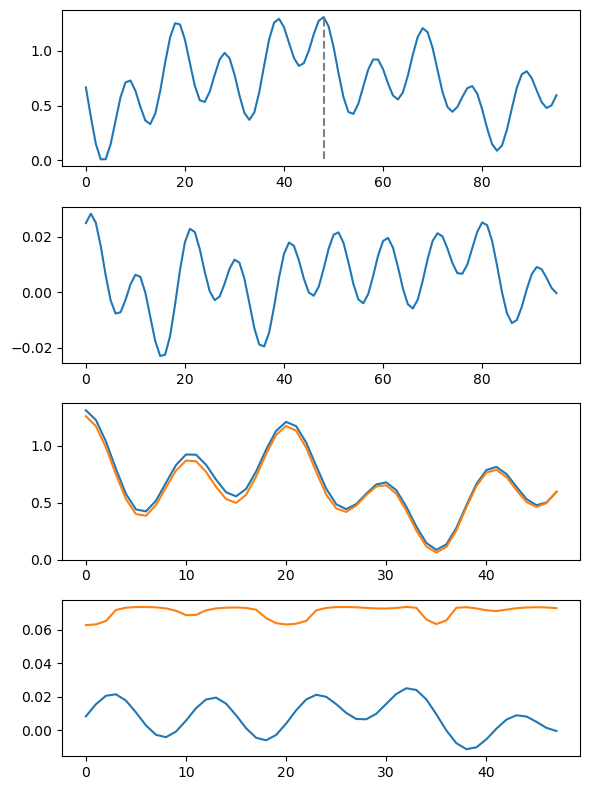

In [15]:
jdata = 0

policy.eval()
with torch.no_grad():
    for back, fore in test_loader:
        sa = back[[jdata]]
        sa_next = fore[[jdata]]
        sa_total = torch.cat([sa, sa_next], dim=1)

        model_output = model(sa)

        s_next = model_output[0][:, args.lookback_nsample:]
        a_next = policy(s_next)

        plt.figure(figsize=(6,8))

        sa_total_xmin = torch.min(sa_total[0, :, 0])
        sa_total_xmax = torch.max(sa_total[0, :, 0])
        plt.subplot(4,1,1)
        plt.plot(sa_total[0, :, 0])
        plt.plot([48, 48], [sa_total_xmin, sa_total_xmax], color='gray', linestyle='dashed')

        plt.subplot(4,1,2)
        plt.plot(sa_total[0, :, 1])

        plt.subplot(4,1,3)
        plt.plot(sa_next[0, :, 0])
        plt.plot(s_next[0, :, 0])

        plt.subplot(4,1,4)
        plt.plot(sa_next[0, : , 1])
        plt.plot(a_next[0, :, 0])

        plt.tight_layout()
        plt.show()
        break

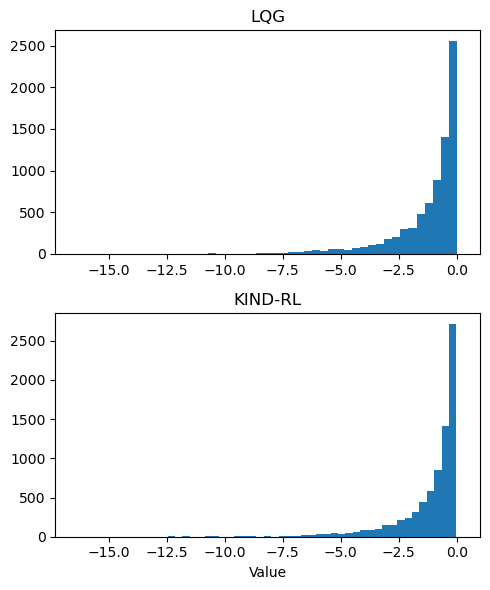

In [13]:
v_lqg = []
v_nn = []

policy.eval()
with torch.no_grad():
    for sa, sa_next in test_loader:
        v_lqg.append(return_fun(reward_fun(sa_next)))

        model_output = model(sa)
        s_next = model_output[0][:, args.lookback_nsample:]
        a_next = policy(s_next)
        sa_next = torch.cat([s_next, a_next], dim=-1)
        v_nn.append(return_fun(reward_fun(sa_next)))

    v_lqg = torch.cat(v_lqg, dim=0)
    v_nn = torch.cat(v_nn, dim=0)

    plt.figure(figsize=(5,6))
    v_min = torch.min(v_lqg)

    plt.subplot(2,1,1)
    plt.title('LQG')
    plt.hist(v_lqg.flatten(), bins=50)
    plt.xlim((v_min, 1))

    plt.subplot(2,1,2)
    plt.title('KIND-RL')
    plt.hist(v_nn.flatten(), bins=50)
    plt.xlim((v_min, 1))
    plt.xlabel('Value')

    plt.tight_layout()
    plt.show()
        
#plt.scatter(detuning.flatten(), control.flatten(), alpha=0.2)